In [6]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import xarray as xr
import numpy as np
import os
from glob import glob
from mpl_toolkits.basemap import Basemap
from numpy import meshgrid
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter, LatitudeLocator
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, TwoSlopeNorm
import pandas as pd
import math
from datetime import datetime
import datetime as dt
from ridgeplot import ridgeplot
import joypy
import seaborn as sns
from matplotlib import cm
import climpred
from xclim import sdba
from climpred.options import OPTIONS
import json
from sklearn.metrics import roc_curve, auc, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from matplotlib.lines import Line2D  # For custom legend entries
import warnings
from sklearn.exceptions import UndefinedMetricWarning
import matplotlib.gridspec as gridspec
import hydroeval as he
import re
from matplotlib.ticker import FormatStrFormatter
import os
import pickle

from function import preprocessUtils as putils
from function import masks
from function import verifications
from function import funs as f
from function import conf
from function import loadbias
from function import dataLoad



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
week_lead=3
obs_source='GLEAM'

In [13]:
with open(f'Data/percentage_of_ACC/Wk{week_lead}_china_ACC_{obs_source}.pkl', 'rb') as f:
    china = pickle.load(f)

with open(f'Data/percentage_of_ACC/Wk{week_lead}_australia_ACC_{obs_source}.pkl', 'rb') as f:
    australia = pickle.load(f)

ex1='EX29'

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def save_ACC_threshold_values_no_bias_correction(china, australia, obs_source, week_lead):
    # Prepare the data
    grid_cells_ch = china['total_grid_cells']
    grid_cells_aus = australia['total_grid_cells']

    # Create new plot_dict using the requested structure
    plot_dict = {
        'China\nGEFSv12\n(A)': china['GEFSv12'],
        'Australia\nGEFSv12\n(B)': australia['GEFSv12'],
        'China\nDL-DM_G\n(C)': china[f'{ex1}_regular_RZSM'],
        'Australia\nDL-DM_G\n(D)': australia[f'{ex1}_regular_RZSM'],
    }

    thresholds = sorted(next(iter(plot_dict.values())).keys())
    num_models = len(plot_dict)
    num_thresholds = len(thresholds)

    bar_width = 0.15
    bar_positions = np.arange(num_models)

    # Plotting
    fig, ax = plt.subplots(figsize=(4, 6), dpi=300)
    colors = plt.cm.viridis(np.linspace(0, 1, num_thresholds))

    for i, threshold in enumerate(thresholds):
        values = [plot_dict[model][threshold] for model in plot_dict]
        ax.bar(bar_positions + i * bar_width, values, width=bar_width,
               label=f'>{threshold}', color=colors[i])

    ax.set_xticks(bar_positions + (num_thresholds - 1) * bar_width / 2)
    ax.set_xticklabels(plot_dict.keys(), fontsize=9)
    ax.set_ylabel('Proportion of grid cells')
    ax.set_title(f"Proportion of Skill Scores Above Thresholds\nChina N = {grid_cells_ch}; Australia N = {grid_cells_aus}", fontsize=10)
    ax.legend(title='ACC Thresholds', loc='upper left')
    ax.grid(axis='y', linestyle='--', linewidth=0.5)

    save_dir = 'Outputs/bar_plot'
    os.makedirs(save_dir, exist_ok=True)
    plt.tight_layout()
    plt.savefig(f'{save_dir}/Wk{week_lead}_ACC_CHINA_AUS_plots_above_ACC_threshold_{obs_source}.png')
    plt.show()


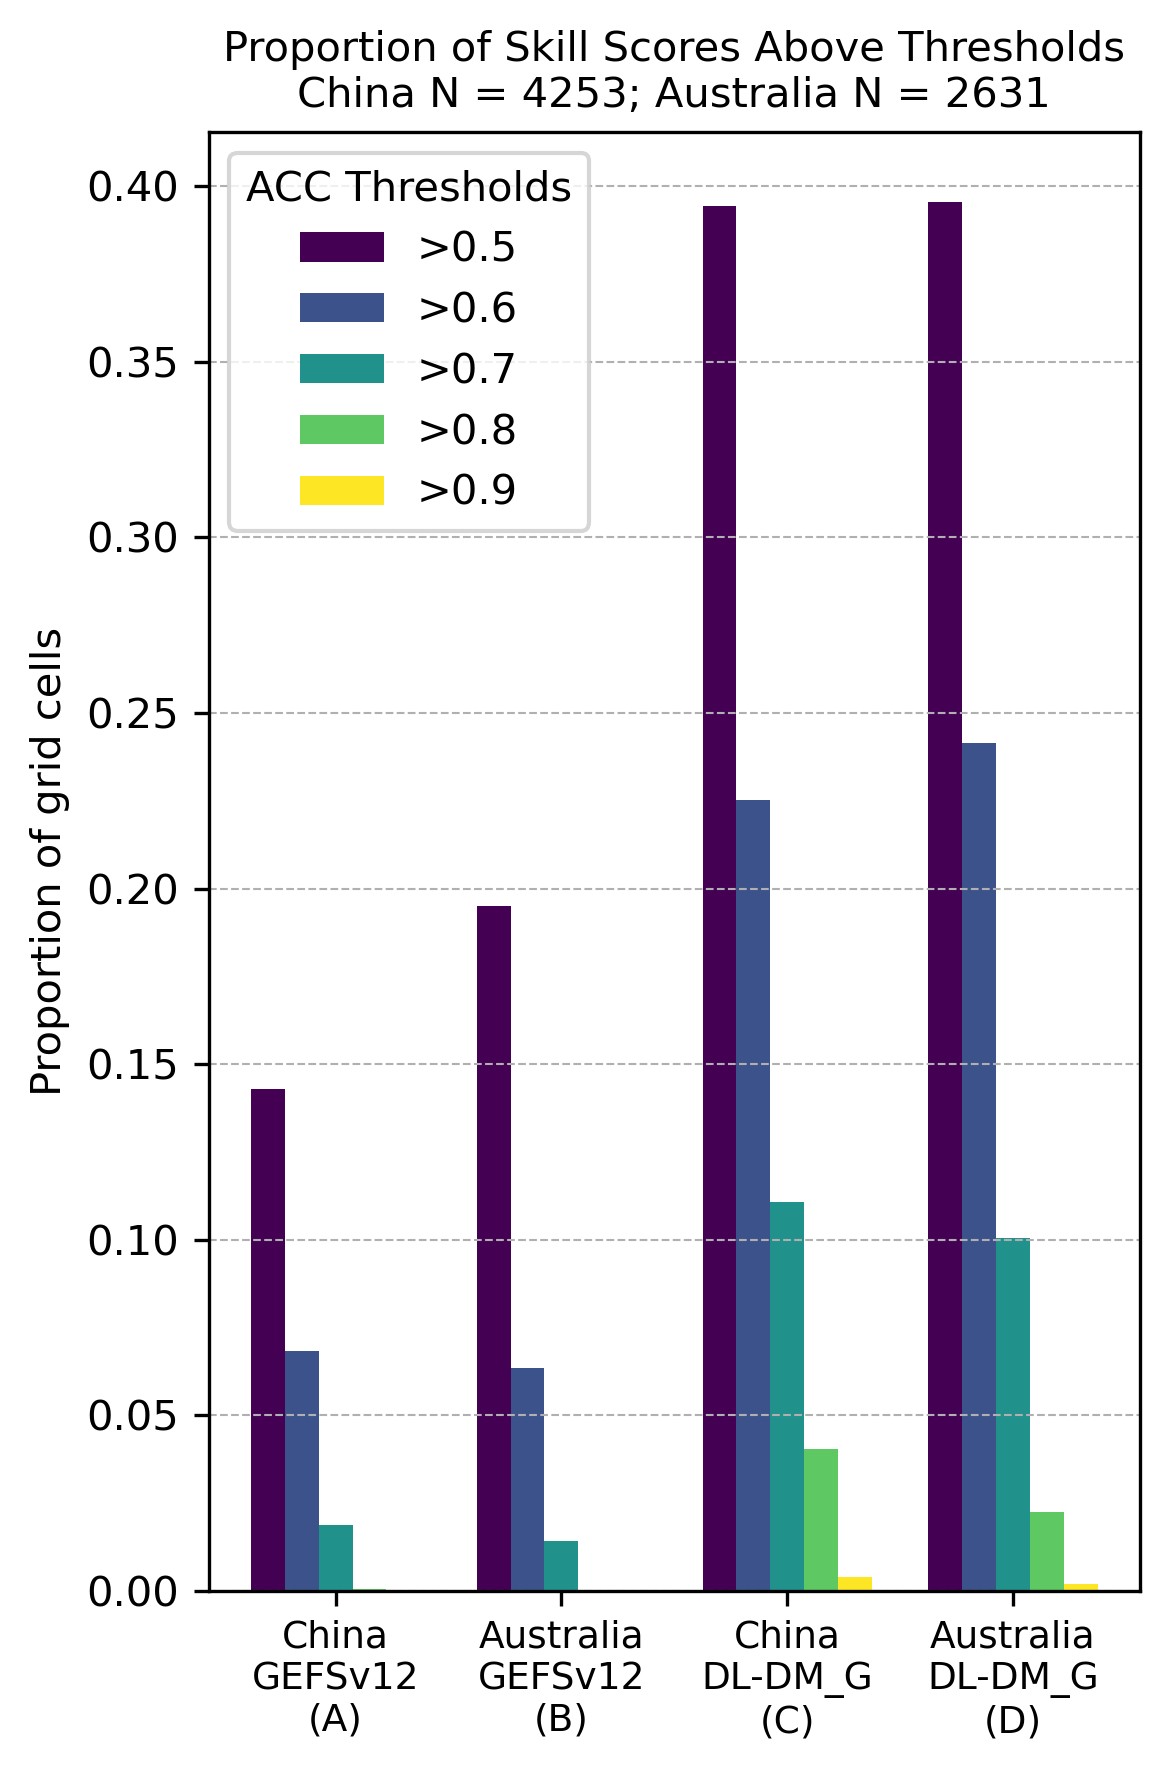

In [33]:
save_ACC_threshold_values_no_bias_correction(china, australia, obs_source, week_lead)